In [189]:
import numpy as np
import pandas as pd
import os
from scipy.interpolate import interp1d

# Paths
ESP32_DATA_PATH = "/Users/aleynagulkazdal/Desktop/esp32_data"
WIAR_DATA_PATH = "../data"

# Parametreler
TARGET_FRAMES = 300
TARGET_SC = 90

# Aktivite mapping 
ACTIVITY_MAP = {
    "horizontal_arm_wave": 0,   # WIAR 01
    "two_hands_wave": 2,        # WIAR 03
    "forward_kick": 7,          # WIAR 08
    "bend": 9,                  # WIAR 10
    "hand_clap": 10,            # WIAR 11
    "walk": 11,                 # WIAR 12
    "sit_down": 14,             # WIAR 15
    "squat": 15,                # WIAR 16
    "still": 16                 # Yeni sınıf WIAR'da yok, ESP32'de "still" olarak adlandırıldı
}

# Kullanıcı mapping 
USER_MAP = {
    "aleyna": 8,
    "damla": 9,
    "deniz": 10,
    "derya": 11
}

print("Importlar tamam!")
print(f"Aktivite sayısı: {len(ACTIVITY_MAP)}")
print(f"Kullanıcı sayısı: {len(USER_MAP)}")

Importlar tamam!
Aktivite sayısı: 9
Kullanıcı sayısı: 4


In [190]:
#yeni user map
USER_MAP = {
    "aleyna": 12,
    "damla": 13,
    "deniz": 14,
    "derya": 15
}

print("Yeni USER_MAP:", USER_MAP)

Yeni USER_MAP: {'aleyna': 12, 'damla': 13, 'deniz': 14, 'derya': 15}


In [191]:
def parse_esp32_csv(filepath):
    # Tüm satırları tek tek oku, hatalıları atla
    rows = []
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    header = lines[0].strip().split(',')
    expected_cols = len(header)
    
    for line in lines[1:]:
        vals = line.strip().split(',')
        if len(vals) == expected_cols:
            try:
                rows.append([float(v) for v in vals])
            except:
                continue
    
    if len(rows) == 0:
        raise ValueError("Hiç satır yüklenemedi!")
    
    raw = np.array(rows)
    
    # sc_ sütunları → time hariç
    raw = raw[:, 1:]  # time sütununu at
    
    # İlk 4 değer header, at
    raw = raw[:, 4:]
    
    # Real + Imag → Amplitude
    real = raw[:, 0::2]
    imag = raw[:, 1::2]
    
    if real.shape[1] != imag.shape[1]:
        min_sc = min(real.shape[1], imag.shape[1])
        real = real[:, :min_sc]
        imag = imag[:, :min_sc]
    
    amp = np.sqrt(real**2 + imag**2)
    
    # → 90 SC interpolate
    x_old = np.linspace(0, 1, amp.shape[1])
    x_new = np.linspace(0, 1, TARGET_SC)
    
    interpolated = np.zeros((amp.shape[0], TARGET_SC))
    for i in range(amp.shape[0]):
        f = interp1d(x_old, amp[i], kind='linear')
        interpolated[i] = f(x_new)
    
    return interpolated

def fix_length(data, target_len=TARGET_FRAMES):
    current_len = data.shape[0]
    if current_len == target_len:
        return data
    
    x_old = np.linspace(0, 1, current_len)
    x_new = np.linspace(0, 1, target_len)
    
    # Her bir subcarrier (90 tane) için zaman ekseninde interpolasyon
    f = interp1d(x_old, data, axis=0, kind='linear', fill_value="extrapolate")
    return f(x_new)

#normalizasyon fonksiyonu
def normalize_samples(X):
    # Her bir örneği (300x90) kendi içinde 0-1 arasına çeker
    X_min = X.min(axis=(1, 2), keepdims=True)
    X_max = X.max(axis=(1, 2), keepdims=True)
    return (X - X_min) / (X_max - X_min + 1e-8)

In [192]:
X_esp32 = []
y_act_esp32 = []
y_user_esp32 = []

skipped = 0
loaded = 0

for person, user_label in USER_MAP.items():
    person_path = os.path.join(ESP32_DATA_PATH, person)
    if not os.path.exists(person_path):
        print(f"UYARI: {person} klasörü bulunamadı!")
        continue
    
    for activity, act_label in ACTIVITY_MAP.items():
        act_path = os.path.join(person_path, activity)
        if not os.path.exists(act_path):
            print(f"UYARI: {person}/{activity} klasörü bulunamadı!")
            continue
        
        csv_files = [f for f in os.listdir(act_path) if f.endswith(".csv")]
        
        for csv_file in sorted(csv_files):
            filepath = os.path.join(act_path, csv_file)
            try:
                x = parse_esp32_csv(filepath)
                x = fix_length(x)
                
                if x.shape != (300, 90):
                    skipped += 1
                    continue
                
                X_esp32.append(x)
                y_act_esp32.append(act_label)
                y_user_esp32.append(user_label)
                loaded += 1
                
            except Exception as e:
                print(f"HATA: {csv_file} → {e}")
                skipped += 1

X_esp32 = np.array(X_esp32)
y_act_esp32 = np.array(y_act_esp32)
y_user_esp32 = np.array(y_user_esp32)

print(f"Yüklenen: {loaded} | Atlanan: {skipped}")
print(f"X shape: {X_esp32.shape}")
print(f"Aktivite dağılımı: {np.bincount(y_act_esp32)}")
print(f"Kullanıcı dağılımı: {np.bincount(y_user_esp32)}")

Yüklenen: 720 | Atlanan: 0
X shape: (720, 300, 90)
Aktivite dağılımı: [80  0 80  0  0  0  0 80  0 80 80 80  0  0 80 80 80]
Kullanıcı dağılımı: [  0   0   0   0   0   0   0   0   0   0   0   0 180 180 180 180]


In [193]:
# NaN kontrolü
nan_count = np.isnan(X_esp32).sum()
print(f"NaN sayısı: {nan_count}")
print(f"NaN olan örnek sayısı: {np.isnan(X_esp32).any(axis=(1,2)).sum()}")

# NaN'ları 0 ile doldur
X_esp32_clean = np.nan_to_num(X_esp32, nan=0.0)

print(f"\nTemizleme sonrası:")
print(f"Min: {X_esp32_clean.min():.2f} | Max: {X_esp32_clean.max():.2f} | Mean: {X_esp32_clean.mean():.2f}")

NaN sayısı: 243000
NaN olan örnek sayısı: 9

Temizleme sonrası:
Min: -0.00 | Max: 90.19 | Mean: 17.11


In [194]:
# NaN olan örnekleri çıkar
nan_mask = ~np.isnan(X_esp32).any(axis=(1,2))
X_esp32_clean = X_esp32[nan_mask]
y_act_esp32_clean = y_act_esp32[nan_mask]
y_user_esp32_clean = y_user_esp32[nan_mask]

print(f"Temiz örnek sayısı: {len(X_esp32_clean)}")
print(f"Atılan NaN örnek: {(~nan_mask).sum()}")
print(f"Aktivite dağılımı: {np.bincount(y_act_esp32_clean)}")
print(f"Kullanıcı dağılımı: {np.bincount(y_user_esp32_clean)}")

Temiz örnek sayısı: 711
Atılan NaN örnek: 9
Aktivite dağılımı: [78  0 79  0  0  0  0 78  0 79 79 79  0  0 79 80 80]
Kullanıcı dağılımı: [  0   0   0   0   0   0   0   0   0   0   0   0 179 177 178 177]


In [195]:
# WIAR verisini yükle
X_wiar = np.load("../data/X.npy")
y_act_wiar = np.load("../data/y_act.npy")
y_user_wiar = np.load("../data/y_user.npy")

print(f"WIAR shape: {X_wiar.shape}")

WIAR shape: (3521, 300, 90)


In [196]:
# Birleştir
X_combined = np.vstack([X_wiar, X_esp32_clean])
y_act_combined = np.concatenate([y_act_wiar, y_act_esp32_clean])
y_user_combined = np.concatenate([y_user_wiar, y_user_esp32_clean])

print(f"Birleştirilmiş X shape: {X_combined.shape}")
print(f"Toplam örnek: {len(X_combined)}")
print(f"Toplam aktivite sınıfı: {len(np.unique(y_act_combined))}")
print(f"Toplam kullanıcı: {len(np.unique(y_user_combined))}")
print(f"\nAktivite dağılımı: {np.bincount(y_act_combined)}")
print(f"Kullanıcı dağılımı: {np.bincount(y_user_combined)}")

# Çakışma kontrolü
overlap = set(np.unique(y_user_wiar)) & set(np.unique(y_user_esp32_clean))
print(f"\nÇakışan kullanıcılar: {overlap}")

Birleştirilmiş X shape: (4232, 300, 90)
Toplam örnek: 4232
Toplam aktivite sınıfı: 17
Toplam kullanıcı: 12

Aktivite dağılımı: [298 220 299 220 221 220 220 298 220 299 299 299 220 220 299 300  80]
Kullanıcı dağılımı: [480 480 480 480   0   0 481 480 480 160   0   0 179 177 178 177]

Çakışan kullanıcılar: set()


In [197]:
# Kaydet
np.save("../data/X_combined.npy", X_combined)
np.save("../data/y_act_combined.npy", y_act_combined)
np.save("../data/y_user_combined.npy", y_user_combined)

print("Kaydedildi!")
print(f"X_combined: {X_combined.shape}")
print(f"y_act_combined: {y_act_combined.shape}")
print(f"y_user_combined: {y_user_combined.shape}")

Kaydedildi!
X_combined: (4232, 300, 90)
y_act_combined: (4232,)
y_user_combined: (4232,)


In [198]:
from sklearn.model_selection import train_test_split

# Sadece ESP32 verisi
X_train, X_test, y_act_train, y_act_test, y_user_train, y_user_test = train_test_split(
    X_esp32_clean, 
    y_act_esp32_clean, 
    y_user_esp32_clean,
    test_size=0.2, 
    random_state=42,
    stratify=y_act_esp32_clean
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")
print(f"Train aktivite dağılımı: {np.bincount(y_act_train)}")
print(f"Train kullanıcı dağılımı: {np.bincount(y_user_train)}")

Train: (568, 300, 90)
Test: (143, 300, 90)
Train aktivite dağılımı: [63  0 63  0  0  0  0 62  0 63 63 63  0  0 63 64 64]
Train kullanıcı dağılımı: [  0   0   0   0   0   0   0   0   0   0   0   0 140 143 150 135]


In [199]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_dual_task_model():
    input_layer = layers.Input(shape=(300, 90))

    # Özellik Çıkarıcı Katmanlar (Ortak Gövde)
    x = layers.Conv1D(64, 11, padding='same', activation='relu')(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Conv1D(128, 15, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.5)(x)

    x = layers.GlobalAveragePooling1D()(x)

    # 1. KOL: Aktivite Sınıflandırma (Yürüme, El Sallama vb.)
    act_out = layers.Dense(17, activation='softmax', name='activity_output')(x)

    # 2. KOL: Kullanıcı Tanıma (Aleyna, Damla vb.)
    # Toplam 16 kullanıcı var (WIAR + Sizin ekip)
    user_out = layers.Dense(20, activation='softmax', name='user_output')(x)

    model = Model(inputs=input_layer, outputs=[act_out, user_out])
    
    model.compile(
    optimizer='adam',
    loss={
        'activity_output': 'sparse_categorical_crossentropy',
        'user_output': 'sparse_categorical_crossentropy'
    },
    # Aktiviteye 2 kat daha fazla önem ver (Kişi tanımayı zaten biliyor)
    loss_weights={
        'activity_output': 2.0, 
        'user_output': 1.0
    },
    metrics={
        'activity_output': 'accuracy',
        'user_output': 'accuracy'
    }
)
    return model

model = build_dual_task_model()
model.summary() # Modelin yapısını kontrol etmeni sağlar

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 300, 90)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_42 (Conv1D)  │ (None, 300, 64)   │     63,424 │ input_layer_19[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_42[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_35    │ (None, 150, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 150, 64)   │          0 │ max_pooling1d_35… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_43 (Conv1D)  │ (None, 150, 128)  │    123,008 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 128)  │        512 │ conv1d_43[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_36    │ (None, 75, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 75, 128)   │          0 │ max_pooling1d_36… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ dropout_27[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activity_output     │ (None, 17)        │      2,193 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_output (Dense) │ (None, 20)        │      2,580 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 191,973 (749.89 KB)

 Trainable params: 191,589 (748.39 KB)

 Non-trainable params: 384 (1.50 KB)

In [200]:
# Bekçiyi daha detaylı tanımlıyoruz
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_activity_output_accuracy', 
        patience=10, 
        restore_best_weights=True,
        mode='max'  # <--- "En yüksek değeri kovala" dedik
    )
]

history = model.fit(
    X_train_norm, 
    {
        'activity_output': y_act_train, 
        'user_output': y_user_train
    },
    validation_data=(X_test_norm, {
        'activity_output': y_act_test, 
        'user_output': y_user_test
    }),
    epochs=50, 
    batch_size=32,
    callbacks=my_callbacks
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - activity_output_accuracy: 0.1901 - activity_output_loss: 2.8951 - loss: 7.2763 - user_output_accuracy: 0.7042 - user_output_loss: 1.4585 - val_activity_output_accuracy: 0.1049 - val_activity_output_loss: 3.8900 - val_loss: 10.7813 - val_user_output_accuracy: 0.2657 - val_user_output_loss: 2.8806
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - activity_output_accuracy: 0.3838 - activity_output_loss: 2.0447 - loss: 4.6227 - user_output_accuracy: 0.8803 - user_output_loss: 0.5250 - val_activity_output_accuracy: 0.2238 - val_activity_output_loss: 3.2105 - val_loss: 8.3988 - val_user_output_accuracy: 0.5734 - val_user_output_loss: 1.8344
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - activity_output_accuracy: 0.4824 - activity_output_loss: 1.6868 - loss: 3.7456 - user_output_accuracy: 0.9049 - user_output_loss: 0.3643 - val_activity_output_accuracy: 0.2797 - val_activity_output_loss: 3.0950 - val_loss: 7.6528 - val_user_output_

In [201]:
# Test verileri üzerinde değerlendirme
results = model.evaluate(X_test_norm, 
                         {'activity_output': y_act_test, 'user_output': y_user_test}, 
                         verbose=0)

# Çıktıları isimleriyle eşleştirelim
metrics_names = model.metrics_names
print("--- TEST SONUÇLARI ---")
for name, value in zip(metrics_names, results):
    print(f"{name}: {value:.4f}")

--- TEST SONUÇLARI ---
loss: 3.4774
compile_metrics: 1.6131
activity_output_loss: 0.1871
user_output_loss: 0.6084


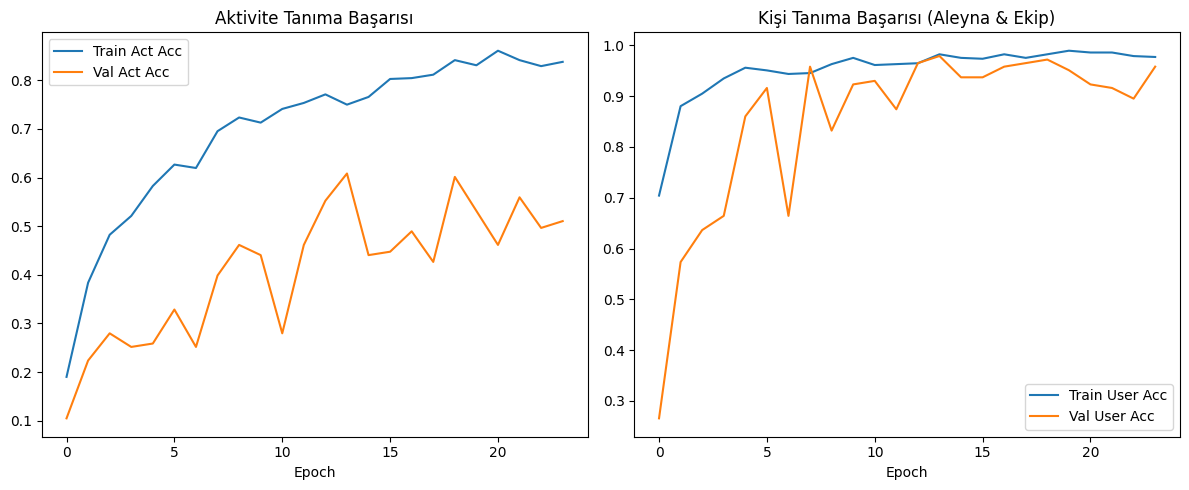

In [202]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Aktivite Başarısı
    plt.subplot(1, 2, 1)
    plt.plot(history.history['activity_output_accuracy'], label='Train Act Acc')
    plt.plot(history.history['val_activity_output_accuracy'], label='Val Act Acc')
    plt.title('Aktivite Tanıma Başarısı')
    plt.xlabel('Epoch')
    plt.legend()

    # Kullanıcı (Kişi) Başarısı
    plt.subplot(1, 2, 2)
    plt.plot(history.history['user_output_accuracy'], label='Train User Acc')
    plt.plot(history.history['val_user_output_accuracy'], label='Val User Acc')
    plt.title('Kişi Tanıma Başarısı (Aleyna & Ekip)')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [203]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import h5py

# Modeli yeniden tanımla (05_multitask ile aynı mimari)
def build_model():
    input_layer = layers.Input(shape=(300, 90))
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    activity_output = layers.Dense(17, activation='softmax', name="activity_head")(x)
    embedding = layers.Dense(128, name="embedding_dense")(x)
    embedding = layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1),
        name="embedding_head"
    )(embedding)
    return Model(inputs=input_layer, outputs=[activity_output, embedding])

base_model = build_model()

# Ağırlıkları yükle
base_model.load_weights("../models/multitask_combined_model.h5")
print("Ağırlıklar yüklendi!")
base_model.summary()

Ağırlıklar yüklendi!


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 300, 90)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_44 (Conv1D)  │ (None, 300, 64)   │     28,864 │ input_layer_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_44[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_37    │ (None, 150, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_45 (Conv1D)  │ (None, 150, 128)  │     24,704 │ max_pooling1d_37… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 128)  │        512 │ conv1d_45[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_38    │ (None, 75, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_46 (Conv1D)  │ (None, 75, 256)   │     98,560 │ max_pooling1d_38… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 256)   │      1,024 │ conv1d_46[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dense     │ (None, 128)       │     32,896 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activity_head       │ (None, 17)        │      4,369 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_head      │ (None, 128)       │          0 │ embedding_dense[… │
│ (Lambda)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 191,185 (746.82 KB)

 Trainable params: 190,289 (743.32 KB)

 Non-trainable params: 896 (3.50 KB)

In [204]:
# Hepsini sıfırla, sıfırdan eğit
for layer in base_model.layers:
    layer.trainable = True

base_model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss={
        'activity_head': 'sparse_categorical_crossentropy',
        'embedding_head': lambda y_true, y_pred: tf.constant(0.0)
    },
    metrics={
        'activity_head': 'accuracy',
        'embedding_head': []
    }
)

history_ft = base_model.fit(
    X_train_norm,
    {'activity_head': y_act_train, 'embedding_head': np.zeros((len(y_act_train), 128))},
    validation_data=(X_test_norm, {'activity_head': y_act_test, 'embedding_head': np.zeros((len(y_act_test), 128))}),
    epochs=50,
    batch_size=16
)

results = base_model.evaluate(X_test_norm, {'activity_head': y_act_test, 'embedding_head': np.zeros((len(y_act_test), 128))}, verbose=0)
print(f"\nActivity Accuracy: {results[3]:.4f}")

Epoch 1/50


/opt/anaconda3/envs/csi_env/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['embedding_dense/kernel', 'embedding_dense/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - activity_head_accuracy: 0.4613 - activity_head_loss: 1.8421 - embedding_head_loss: 0.0000e+00 - loss: 1.8463 - val_activity_head_accuracy: 0.1049 - val_activity_head_loss: 4.7621 - val_embedding_head_loss: 0.0000e+00 - val_loss: 4.7646
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - activity_head_accuracy: 0.5722 - activity_head_loss: 1.3897 - embedding_head_loss: 0.0000e+00 - loss: 1.3875 - val_activity_head_accuracy: 0.1119 - val_activity_head_loss: 4.9706 - val_embedding_head_loss: 0.0000e+00 - val_loss: 4.9727
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - activity_head_accuracy: 0.6708 - activity_head_loss: 1.1599 - embedding_head_loss: 0.0000e+00 - loss: 1.1614 - val_activity_head_accuracy: 0.1399 - val_activity_head_loss: 4.4720 - val_embedding_head_loss: 0.0000e+00 - val_loss: 4.4741
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - activity_head_accuracy: 0.6972 - activity_head_loss: 1.0358 - embedding_head_loss: 0.0000e+

In [205]:
base_model.save("../models/esp32_finetuned_model.h5")
print("Model kaydedildi!")

Model kaydedildi!


In [206]:
# Embedding çıkar
embedding_model = Model(
    inputs=base_model.input,
    outputs=base_model.get_layer("embedding_head").output
)

# Train ve test embedding'leri
train_embeddings = embedding_model.predict(X_train_norm, verbose=0)
test_embeddings = embedding_model.predict(X_test_norm, verbose=0)

# Normalize
from sklearn.preprocessing import normalize
train_embeddings = normalize(train_embeddings, axis=1)
test_embeddings = normalize(test_embeddings, axis=1)

# Gallery oluştur (her kullanıcı için ortalama embedding)
gallery = {}
for user in np.unique(y_user_train):
    mask = y_user_train == user
    user_embs = train_embeddings[mask]
    mean_emb = np.mean(user_embs, axis=0)
    gallery[user] = mean_emb / np.linalg.norm(mean_emb)

print("Gallery users:", list(gallery.keys()))

# Kullanıcı tanıma accuracy
correct = 0
for i in range(len(test_embeddings)):
    sims = {u: np.dot(test_embeddings[i], gallery[u]) for u in gallery}
    pred = max(sims, key=sims.get)
    if pred == y_user_test[i]:
        correct += 1

acc = correct / len(test_embeddings)
print(f"User Identification Accuracy: {acc:.4f}")

Gallery users: [np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
User Identification Accuracy: 0.9231


In [207]:
# Modeli kaydet
base_model.save("../models/esp32_finetuned_model.h5")
print("Model kaydedildi!")

Model kaydedildi!


In [208]:
import tensorflow as tf
import numpy as np

# 1. MİMARİYİ TEKRAR TANIMLA (Hücre 142'deki ile aynı olmalı)
def build_final_architecture():
    input_layer = tf.keras.layers.Input(shape=(300, 90))
    
    # Ortak Gövde (CNN Katmanları)
    x = tf.keras.layers.Conv1D(64, 5, padding='same', activation='relu')(input_layer)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    
    x = tf.keras.layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    
    x = tf.keras.layers.Conv1D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    
    # Başlıklar
    activity_output = tf.keras.layers.Dense(17, activation='softmax', name="activity_head")(x)
    
    embedding = tf.keras.layers.Dense(128, name="embedding_dense")(x)
    embedding = tf.keras.layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1),
        name="embedding_head"
    )(embedding)
    
    return tf.keras.Model(inputs=input_layer, outputs=[activity_output, embedding])

# 2. Boş modeli oluştur
final_model = build_final_architecture()

# 3. Sadece ağırlıkları (weights) dosyadan yükle
# Bu yöntem Lambda katmanının iç yapısına bakmaz, sadece sayısal değerleri yerleştirir
final_model.load_weights("../models/esp32_finetuned_model.h5")

# 4. Verileri yükle
X_comb = np.load("../data/X_combined.npy")
y_act_comb = np.load("../data/y_act_combined.npy")
y_user_comb = np.load("../data/y_user_combined.npy")

print("Model mimarisi kuruldu ve ağırlıklar başarıyla yüklendi!")

Model mimarisi kuruldu ve ağırlıklar başarıyla yüklendi!


In [209]:
# 1. Kayıp fonksiyonlarını her iki çıkış için de tanımlıyoruz
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={
        'activity_head': 'sparse_categorical_crossentropy',
        'embedding_head': lambda y_true, y_pred: tf.constant(0.0) # Bu çıkışı görmezden gel
    },
    metrics={
        'activity_head': 'accuracy'
    }
)

# 2. Eğitim verisinde her iki başlık için de birer hedef gösteriyoruz
# embedding_head için rastgele sıfırlardan oluşan bir dizi (dummy data) gönderiyoruz
final_model.fit(
    X_comb_norm, 
    {
        'activity_head': y_act_comb,
        'embedding_head': np.zeros((len(y_act_comb), 128)) 
    },
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10


/opt/anaconda3/envs/csi_env/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['embedding_dense/kernel', 'embedding_dense/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - activity_head_accuracy: 0.1195 - activity_head_loss: 3.7241 - embedding_head_loss: 0.0000e+00 - loss: 3.7241 - val_activity_head_accuracy: 0.1792 - val_activity_head_loss: 6.3053 - val_embedding_head_loss: 0.0000e+00 - val_loss: 6.2043
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - activity_head_accuracy: 0.1568 - activity_head_loss: 3.0469 - embedding_head_loss: 0.0000e+00 - loss: 3.0469 - val_activity_head_accuracy: 0.2807 - val_activity_head_loss: 3.8017 - val_embedding_head_loss: 0.0000e+00 - val_loss: 3.6844
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - activity_head_accuracy: 0.2004 - activity_head_loss: 2.7131 - embedding_head_loss: 0.0000e+00 - loss: 2.7131 - val_activity_head_accuracy: 0.3608 - val_activity_head_loss: 2.6507 - val_embedding_head_loss: 0.0000e+00 - val_loss: 2.5496
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - activity_head_accuracy: 0.2408 - activity_head_loss: 2.4975 - embedding_head_loss: 

In [210]:
# 1. Combined etiketlerin içindeki benzersiz kullanıcıları kontrol et
unique_users = np.unique(y_user_combined) # y_user_combined değişken isminden emin ol
print(f"Tespit edilen benzersiz kullanıcı ID'leri: {unique_users}")

# 2. Gallery'yi tekrar oluştur
final_gallery = {}

# Önemli: normalize edilmiş combined veriyi kullanıyoruz
all_embeddings = final_embedding_model.predict(X_comb_norm, verbose=0)

for user_id in unique_users:
    # Bu kullanıcıya ait tüm örnekleri bul
    mask = y_user_combined == user_id
    user_embs = all_embeddings[mask]
    
    if len(user_embs) > 0:
        # Ortalamasını al ve L2 normalize et (Parmak izi oluştur)
        mean_emb = np.mean(user_embs, axis=0)
        final_gallery[user_id] = mean_emb / np.linalg.norm(mean_emb)

print(f"✅ Başarılı! Final Gallery güncellendi. Toplam kişi sayısı: {len(final_gallery)}")

Tespit edilen benzersiz kullanıcı ID'leri: [ 0  1  2  3  6  7  8  9 12 13 14 15]
✅ Başarılı! Final Gallery güncellendi. Toplam kişi sayısı: 12
